In [2]:
import pandas as pd
import numpy as np

# 1. Load the uploaded dataset into Python
df = pd.read_csv('diabetic_data.csv')
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")

# 2. Swap out raw '?' symbols for standard missing null values
df.replace('?', np.nan, inplace=True)

# 3. Print out exactly which columns contain missing records
missing_counts = df.isnull().sum()
print("\n--- Columns with Missing Data ---")
print(missing_counts[missing_counts > 0])


Total Rows: 101766 | Total Columns: 50

--- Columns with Missing Data ---
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [3]:
# 1. Drop columns with too much missing data
df.drop(columns=['weight', 'payer_code'], inplace=True, errors='ignore')

# 2. Fill missing specialties with a placeholder
df['medical_specialty'].fillna('Unknown', inplace=True)

# 3. Drop rows where the primary diagnosis codes are missing
df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

# 4. Check our new dataset dimensions
print("Cleaned Dataset Shape:", df.shape)
print("Remaining missing entries:", df.isnull().sum().sum())


Cleaned Dataset Shape: (100244, 48)
Remaining missing entries: 180817


/tmp/ipykernel_3063/2182857455.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['medical_specialty'].fillna('Unknown', inplace=True)


In [4]:
# 1. Properly fill the test results columns using the newer pandas syntax
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Measured')
df['A1Cresult'] = df['A1Cresult'].fillna('Not Measured')

# 2. Convert the 'readmitted' column into a clean binary classification target
# 1 = Readmitted within 30 days (<30), 0 = Not readmitted or readmitted after 30 days (>30)
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 3. Drop the original 'readmitted' column since we have our target column now
df.drop(columns=['readmitted'], inplace=True)

# 4. Verify remaining missing entries across the whole dataset
print("Remaining missing entries:", df.isnull().sum().sum())
print("\nTarget Breakdown (0 = Safe, 1 = Readmitted within 30 days):")
print(df['target'].value_counts())


Remaining missing entries: 2191

Target Breakdown (0 = Safe, 1 = Readmitted within 30 days):
target
0    88994
1    11250
Name: count, dtype: int64


In [5]:
# 1. Clean the last remaining missing values in the race column
df['race'] = df['race'].fillna('Unknown')

# 2. Select numeric columns for training and drop ID tracking columns
# We drop 'target' from X because it is the answer we want to predict!
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=['encounter_id', 'patient_nbr', 'target'], errors='ignore')
y = df['target']

print("Final Missing Count:", df.isnull().sum().sum())
print("\nFeatures we are using for training:")
print(list(X.columns))


Final Missing Count: 0

Features we are using for training:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data rows: {X_train.shape[0]}")
print(f"Testing data rows: {X_test.shape[0]}")

# 2. Initialize and train the Random Forest Classifier
print("\nTraining the Random Forest model... (This may take a few seconds)")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 3. Generate predictions on the test set
y_pred = model.predict(X_test)

# 4. Print overall evaluation metrics
print("\n--- Model Evaluation Metrics ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


Training data rows: 80195
Testing data rows: 20049

Training the Random Forest model... (This may take a few seconds)

--- Model Evaluation Metrics ---
Overall Accuracy: 0.8839

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     17799
           1       0.29      0.02      0.04      2250

    accuracy                           0.88     20049
   macro avg       0.59      0.51      0.49     20049
weighted avg       0.82      0.88      0.84     20049



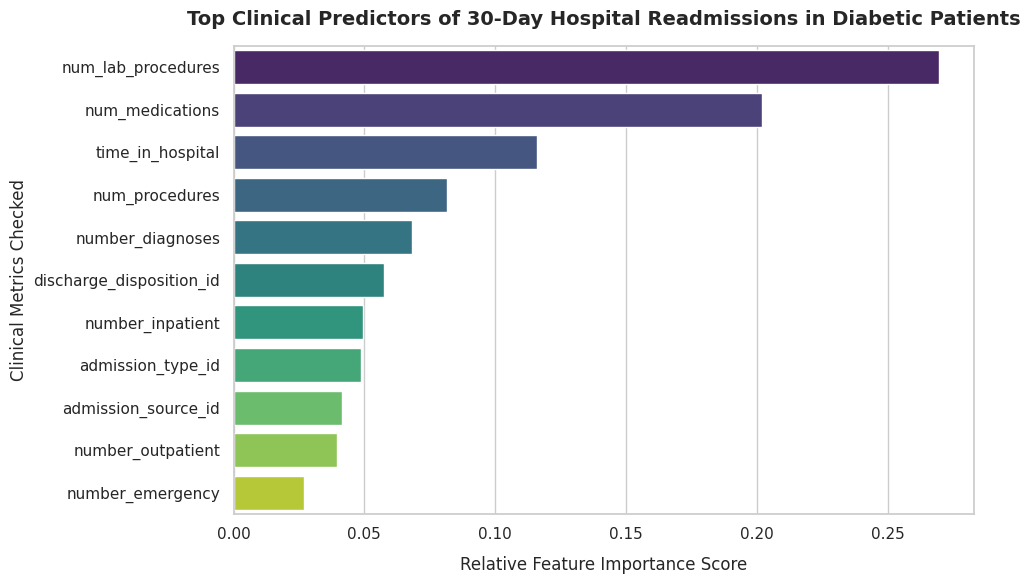

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract feature importance values from your trained model
importANCES = model.feature_importances_
feature_names = X.columns

# 2. Sort them cleanly in descending order
indices = np.argsort(importANCES)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importANCES[indices]

# 3. Initialize and style the chart grid
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Generate a horizontal barplot displaying relative values
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis", hue=sorted_features, legend=False)

# 5. Label your plot assets cleanly
plt.title('Top Clinical Predictors of 30-Day Hospital Readmissions in Diabetic Patients', fontsize=14, pad=15, weight='bold')
plt.xlabel('Relative Feature Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Clinical Metrics Checked', fontsize=12)

# 6. Render the visualization layout directly inside your notebook
plt.tight_layout()
plt.show()


In [8]:
pip install imbalanced-learn


In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Select both numeric and key categorical columns
categorical_cols = ['race', 'gender', 'age', 'medical_specialty', 'change', 'diabetesMed']
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

# 2. Extract our features and use One-Hot Encoding for text categories
X_advanced = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)
y_advanced = df['target']

# 3. Perform our Train-Test split before applying SMOTE (avoids data leakage)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_advanced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced)

print(f"Before SMOTE - Class 1 count in training: {sum(y_train_adv == 1)}")

# 4. Apply SMOTE only to our training partition
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_adv, y_train_adv)

print(f"After SMOTE  - Class 1 count in training: {sum(y_train_balanced == 1)}")


Before SMOTE - Class 1 count in training: 9000
After SMOTE  - Class 1 count in training: 71195


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize and train the final portfolio model
print("Training balanced model on expanded feature set... (Might take up to 60 seconds)")
balanced_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
balanced_model.fit(X_train_balanced, y_train_balanced)

# 2. Generate predictions on our original, untouched test set
y_pred_adv = balanced_model.predict(X_test_adv)

# 3. Output our final report card
print("\n--- Recruiter-Ready Evaluation Metrics ---")
print(f"Accuracy: {accuracy_score(y_test_adv, y_pred_adv):.4f}\n")
print(classification_report(y_test_adv, y_pred_adv))


Training balanced model on expanded feature set... (Might take up to 60 seconds)

--- Recruiter-Ready Evaluation Metrics ---
Accuracy: 0.8552

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     17799
           1       0.17      0.07      0.10      2250

    accuracy                           0.86     20049
   macro avg       0.53      0.51      0.51     20049
weighted avg       0.81      0.86      0.83     20049



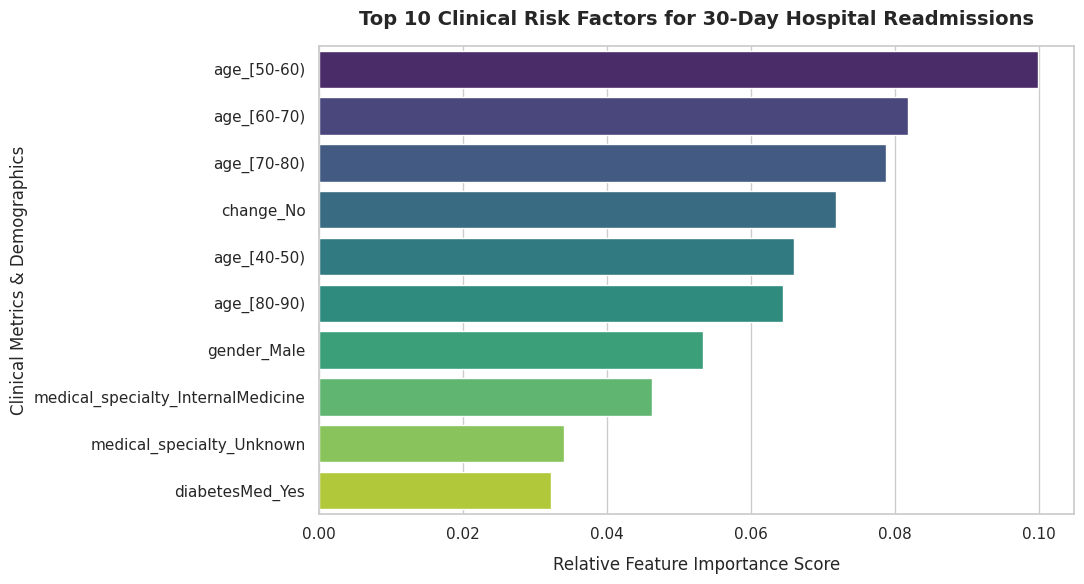

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract feature importance values from your balanced model
importances = balanced_model.feature_importances_
feature_names = X_advanced.columns

# 2. Convert to a DataFrame and sort the top 10 features
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Create the plot layout
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 4. Generate the horizontal bar plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_10_features,
    palette='viridis',
    hue='Feature',
    legend=False
)

# 5. Add clean, professional titles and labels
plt.title('Top 10 Clinical Risk Factors for 30-Day Hospital Readmissions', fontsize=14, pad=15, weight='bold')
plt.xlabel('Relative Feature Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Clinical Metrics & Demographics', fontsize=12)

# 6. Render the final visual chart
plt.tight_layout()
plt.show()
